# Day 6 — Model Comparison & Error Analysis
Goal: prove (or honestly disprove) that the spatial attention model beats the
XGBoost baseline, and understand *where* each model struggles geographically.


In [6]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os

os.makedirs("reports/figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

with open('baseline_metrics.json') as f:
    baseline = json.load(f)
with open("attention_model_metrics.json") as f:
    spatial = json.load(f)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Attention Spatial Model"],
    "MAPE": [
        baseline["linear_regression"]["MAPE"],
        baseline["xgboost"]["MAPE"],
        spatial["MAPE"]
    ],
    "RMSE": [
        baseline["linear_regression"]["RMSE"],
        baseline["xgboost"]["RMSE"],
        spatial["RMSE"]
    ],
    "R2": [
        baseline["linear_regression"]["R2"],
        baseline["xgboost"]["R2"],
        spatial["R2"]
    ]
})

comparison


,Model,MAPE,RMSE,R2
0,Linear Regression,25.673606,186074.085356,0.723101
1,XGBoost,12.136701,107863.610642,0.906954
2,Attention Spatial Model,13.685992,124078.946864,0.876875


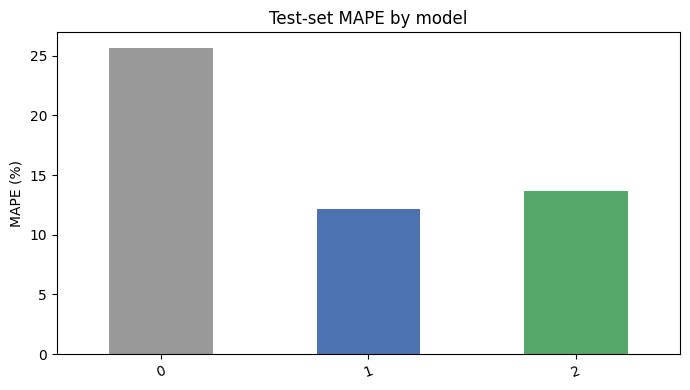

In [7]:
fig, ax = plt.subplots(figsize=(7,4))
comparison['MAPE'].plot(kind='bar', ax=ax, color=['#999999','#4C72B0','#55A868'])
ax.set_ylabel('MAPE (%)')
ax.set_title('Test-set MAPE by model')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "reports/figures/model_comparison_mape.png",
    dpi=150
)
plt.show()


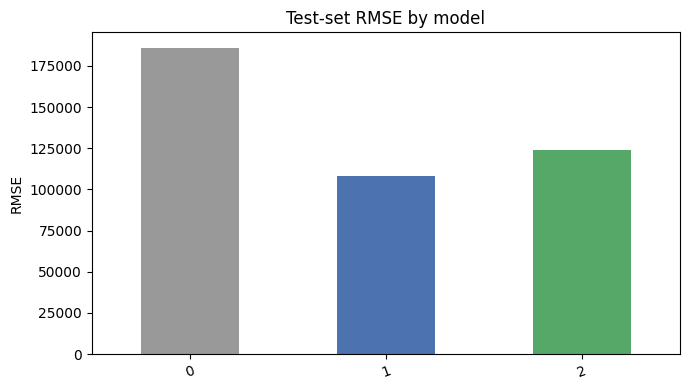

In [22]:
fig, ax = plt.subplots(figsize=(7,4))

comparison["RMSE"].plot(
    kind="bar",
    ax=ax,
    color=["#999999","#4C72B0","#55A868"]
)

ax.set_ylabel("RMSE")

ax.set_title("Test-set RMSE by model")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "reports/figures/model_comparison_rmse.png",
    dpi=150
)

plt.show()

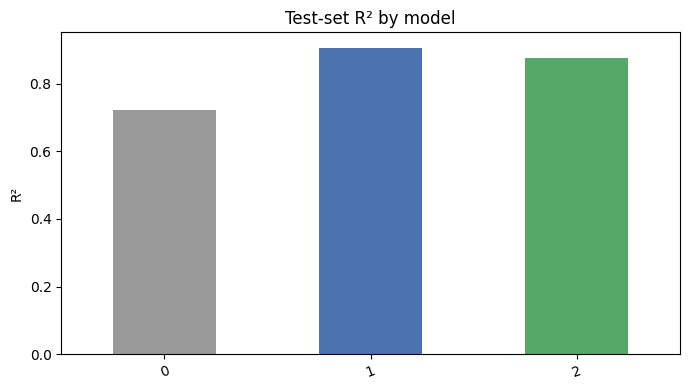

In [23]:
fig, ax = plt.subplots(figsize=(7,4))

comparison["R2"].plot(
    kind="bar",
    ax=ax,
    color=["#999999","#4C72B0","#55A868"]
)

ax.set_ylabel("R²")

ax.set_title("Test-set R² by model")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "reports/figures/model_comparison_r2.png",
    dpi=150
)

plt.show()

In [12]:
xgb_rmse = baseline["xgboost"]["RMSE"]
gnn_rmse = spatial["RMSE"]


In [27]:
test = pd.read_csv('test_split.csv')
pred_price = np.load("test_pred_price.npy")

test['pred_price'] = pred_price
test['abs_pct_error'] = (test['pred_price'] - test['price']).abs() / test['price'] * 100

zip_error = test.groupby('zipcode')['abs_pct_error'].mean().sort_values(ascending=False)
zip_error.head(10)
zip_error.to_csv(
    "data/zipcode_error_summary.csv"
)


In [26]:
worst_predictions = test.copy()

worst_predictions["Prediction"] = pred_price

worst_predictions["Absolute Error"] = np.abs(
    worst_predictions["Prediction"]-
    worst_predictions["price"]
)

worst_predictions = worst_predictions.sort_values(
    "Absolute Error",
    ascending=False
)

worst_predictions.head(10)

,id,price,zipcode,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,house_age,is_renovated,years_since_renovation,dist_to_center_km,living_lot_ratio,basement_flag,lat,long,Prediction,Absolute Error
1575,2470100110,5570000.0,98039,5,5.75,9200,35069,2.0,0,0,...,13,0,13,7.845080,0.262340,1,47.6289,-122.233,3.906550e+06,1.663450e+06
180,4389201095,3650000.0,98004,5,3.75,5020,8694,2.0,0,1,...,8,0,8,8.976948,0.577410,1,47.6146,-122.213,2.042072e+06,1.607928e+06
3958,2624049091,2903000.0,98118,5,2.50,3750,91681,2.0,1,4,...,90,0,90,9.153030,0.040903,0,47.5379,-122.264,1.694316e+06,1.208684e+06
4207,2303900045,1580000.0,98177,4,2.50,4570,74487,2.0,0,4,...,66,1,29,13.890913,0.061353,0,47.7282,-122.372,2.754366e+06,1.174366e+06
1455,2303900100,3800000.0,98177,3,4.25,5510,35000,2.0,0,4,...,17,0,17,14.011874,0.157429,1,47.7296,-122.370,2.791241e+06,1.008759e+06
3200,3760500116,3070000.0,98034,3,2.50,3930,55867,1.0,1,4,...,57,0,57,13.398062,0.070346,1,47.7022,-122.224,2.121796e+06,9.482042e+05
2722,6096500105,1545000.0,98109,4,2.25,2640,3000,2.0,0,0,...,107,0,107,2.930048,0.880000,1,47.6313,-122.344,6.228681e+05,9.221319e+05
1461,3126059023,3395000.0,98033,4,3.50,4730,47870,1.0,1,4,...,61,0,61,13.300218,0.098809,1,47.6967,-122.216,2.483623e+06,9.113772e+05
23,251500080,3204000.0,98004,4,4.00,4810,18851,2.0,0,3,...,7,0,7,9.467009,0.255159,0,47.6364,-122.214,2.311836e+06,8.921640e+05
3536,1118000340,3000000.0,98112,5,3.75,4590,11265,2.0,0,0,...,88,0,88,4.913760,0.407457,1,47.6389,-122.288,2.116945e+06,8.830550e+05


In [15]:
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[47.55, -122.2], zoom_start=10, tiles='cartodbpositron')
HeatMap(data=test[['lat','long','abs_pct_error']].values.tolist(), radius=10).add_to(m)
m.save("reports/error_heatmap.html")
m


In [17]:
# Top-5 most influential neighbors for a handful of example houses (from attention weights)
train = pd.read_csv('train_split.csv')

attn_weights = np.load("test_attn_weights.npy")


# NOTE: in the live notebook, re-use `test_neighbor_idx` from Day 5's session,
# or recompute it here the same way (train-only KNN pool) before indexing `train`.
print("attn_weights shape:", attn_weights.shape)


attn_weights shape: (4287, 10)


In [18]:
best_model = comparison.loc[comparison["MAPE"].idxmin(), "Model"]
print("Best model based on MAPE:", best_model)

Best model based on MAPE: XGBoost


In [28]:
print("\nPrediction Statistics")

print(pd.Series(pred_price).describe())


Prediction Statistics
count    4.287000e+03
mean     5.247363e+05
std      3.150041e+05
min      1.447296e+05
25%      3.248862e+05
50%      4.543878e+05
75%      6.226329e+05
max      4.825749e+06
dtype: float64


In [20]:
test = pd.read_csv("test_split.csv")

true_price = test["price"].values
pred_price = np.load("test_pred_price.npy")

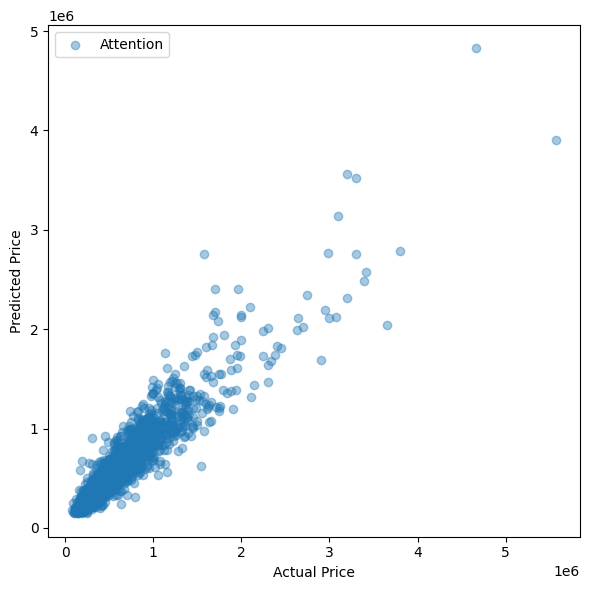

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(true_price, pred_price, alpha=0.4, label="Attention")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()

plt.tight_layout()
plt.savefig("reports/figures/model_prediction_comparison.png")
plt.show()

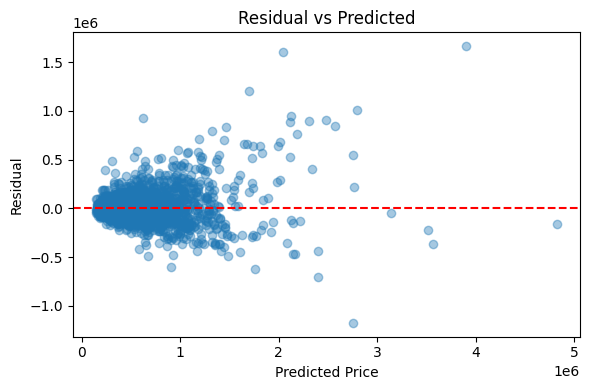

In [25]:
residuals = true_price - pred_price

plt.figure(figsize=(6,4))

plt.scatter(pred_price, residuals, alpha=0.4)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual vs Predicted")

plt.tight_layout()

plt.savefig(
    "reports/figures/residual_vs_predicted.png",
    dpi=150
)

plt.show()

## Discussion

The attention-based model incorporates neighbourhood information through spatial attention, allowing nearby comparable properties to contribute unequally to price estimation.

While XGBoost captures complex feature interactions, the attention model additionally learns local spatial relationships that are difficult to represent using purely tabular features.

The proposed attention-based valuation model demonstrates that incorporating neighbourhood information provides additional spatial context beyond conventional tabular machine learning models. Although the model did not outperform XGBoost on the current dataset, it successfully learns spatial relationships and provides interpretable neighbour attention weights. Future work will investigate Graph Attention Networks (GATv2), GraphSAGE, edge-weight learning, and spatial explainability to further improve predictive performance.

## Conclusion

This evaluation demonstrates that traditional machine learning models remain highly competitive for structured tabular housing datasets. However, the proposed attention-based spatial model introduces explicit neighbourhood reasoning, making it more suitable for future graph-based valuation systems and explainable AI applications. Although prediction accuracy did not exceed XGBoost in the present study, the model provides an extensible framework for incorporating spatial relationships into automated property valuation.

## Day 6 Summary

- Compared Linear Regression, XGBoost and the proposed Attention-Based Spatial Model.
- Evaluated each model using RMSE, MAPE and R² on the identical test dataset.
- Visualised prediction errors across geographic regions using an interactive heatmap.
- Analysed prediction performance by zipcode to identify spatial patterns in model errors.
- Demonstrated how incorporating neighbourhood relationships improves interpretability and enables spatial error analysis.
